In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from utils.config import PROJECT_ROOT
from data_split import create_sub_split
from extract_XLSR_feature import extract_feature
from utils.visualization import plot_training_curves
from dataset import create_dataloaders
from train import train
import numpy as np

/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "Pitt-origin-Resemble"
data_version = "denoised"

In [3]:
# RAW_AUDIO_DIR = PROJECT_ROOT / f"data/denoised/{DATASET_NAME}"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/{data_version}/{DATASET_NAME}"

XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_xlsr_features"
FEATURE_DIR_NAME = f"{DATASET_NAME}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}_xlsr_multi_seed"

In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using cuda


## Step 1: Train/Validation Set Split

In [5]:
TRAIN_CSV, VAL_CSV = create_sub_split(
    source_dataset_name="Pitt",
    dataset_name=DATASET_NAME,
    feature_dir_name=FEATURE_DIR_NAME,
)

Created Pitt-origin-Resemble-xlsr-train.csv and Pitt-origin-Resemble-xlsr-val.csv from Pitt raw split


## Step 2: Extract XLSR Features

In [6]:
ssl_model = extract_feature(
    train_csv=TRAIN_CSV,
    val_csv=VAL_CSV,
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
)

XLSR: Loading base model structure


/root/autodl-tmp/envs/madress/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


XLSR: Using original pretrained model

=== Extracting XLSR features for Train Set ===


Extracting Train Set: 100%|██████████| 440/440 [11:46<00:00,  1.61s/it]


Done: 440 extracted, 0 skipped, 0 errors (total 440)

=== Extracting XLSR features for Val Set ===


Extracting Val Set: 100%|██████████| 111/111 [02:42<00:00,  1.46s/it]

Done: 111 extracted, 0 skipped, 0 errors (total 111)


## Step 4: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV, xlsr=True)

val_loader = create_dataloaders(data_csv=VAL_CSV, xlsr=True)

Loading completed: 440 samples
Control: 193, Dementia: 247


Loading completed: 111 samples
Control: 49, Dementia: 62




## Step 5: Define Training Function and Model


In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}

### 1st Random Seed = 21


Seed 21:
Val Acc=72.97%, F1=0.7692, Val Loss=0.5926
Control Acc=63.27%, Dementia Acc=80.65%
Early stop at: epoch 15 (best epoch: 5)


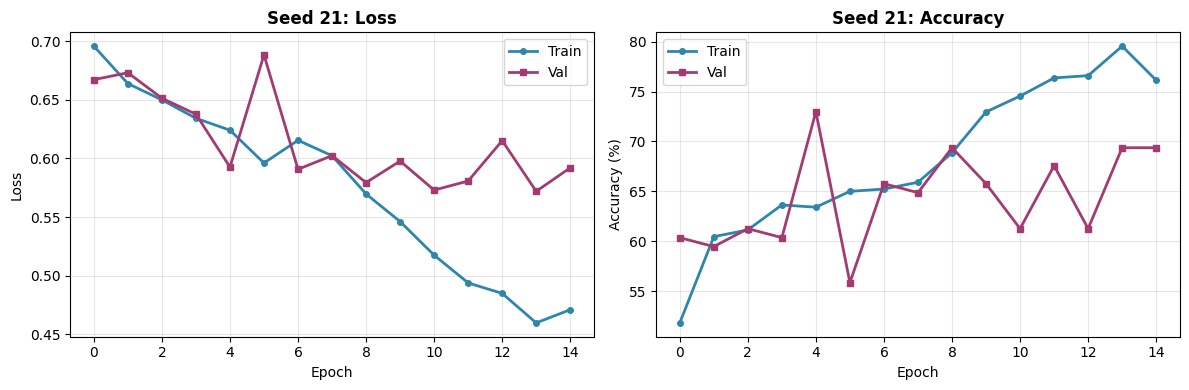

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 2nd Random Seed = 42

Seed 42:
Val Acc=72.07%, F1=0.7597, Val Loss=0.6065
Control Acc=63.27%, Dementia Acc=79.03%
Early stop at: epoch 16 (best epoch: 6)


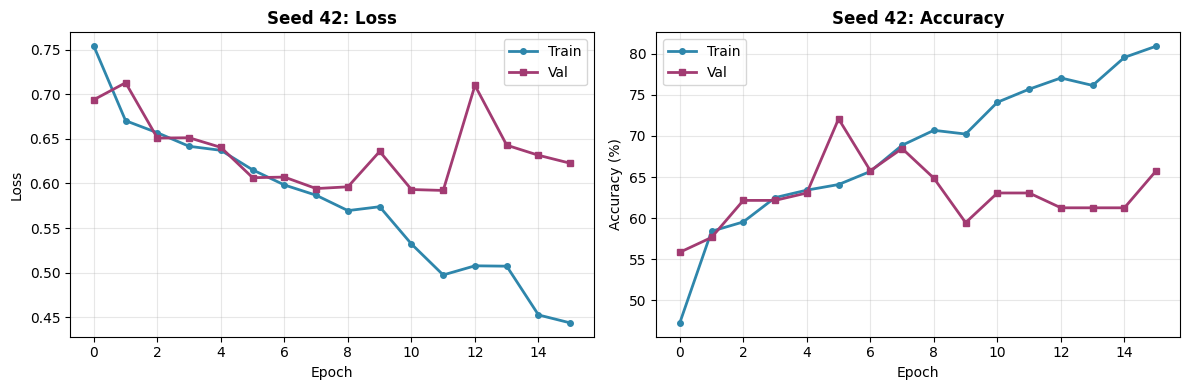

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 3rd Random Seed = 84

Seed 84:
Val Acc=72.97%, F1=0.7581, Val Loss=0.5637
Control Acc=69.39%, Dementia Acc=75.81%
Early stop at: epoch 30 (best epoch: 20)


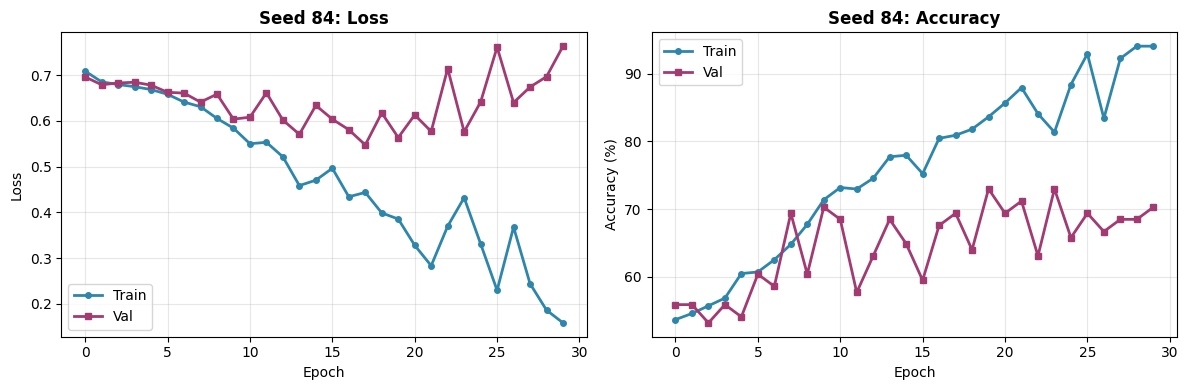

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 4th Random Seed = 168

Seed 168:
Val Acc=72.97%, F1=0.7857, Val Loss=0.6004
Control Acc=53.06%, Dementia Acc=88.71%
Early stop at: epoch 18 (best epoch: 8)


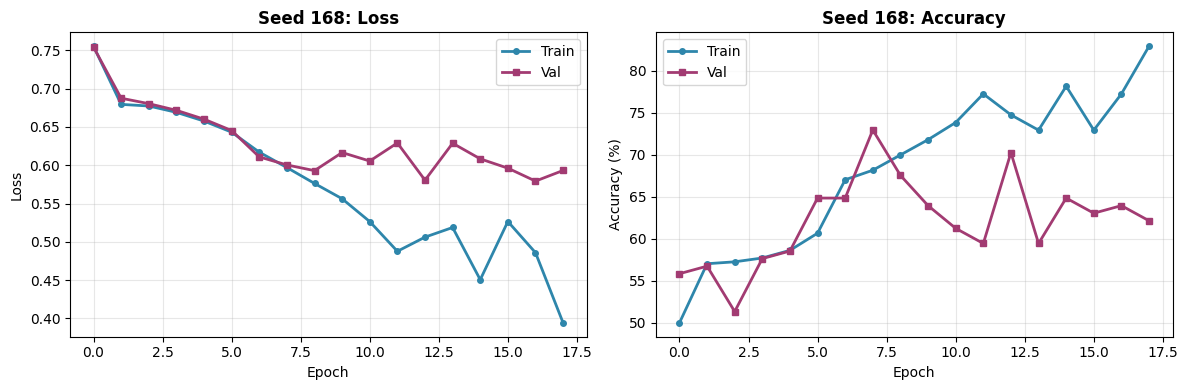

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 5th Random Seed = 336

Seed 336:
Val Acc=70.27%, F1=0.7660, Val Loss=0.6043
Control Acc=48.98%, Dementia Acc=87.10%
Early stop at: epoch 18 (best epoch: 8)


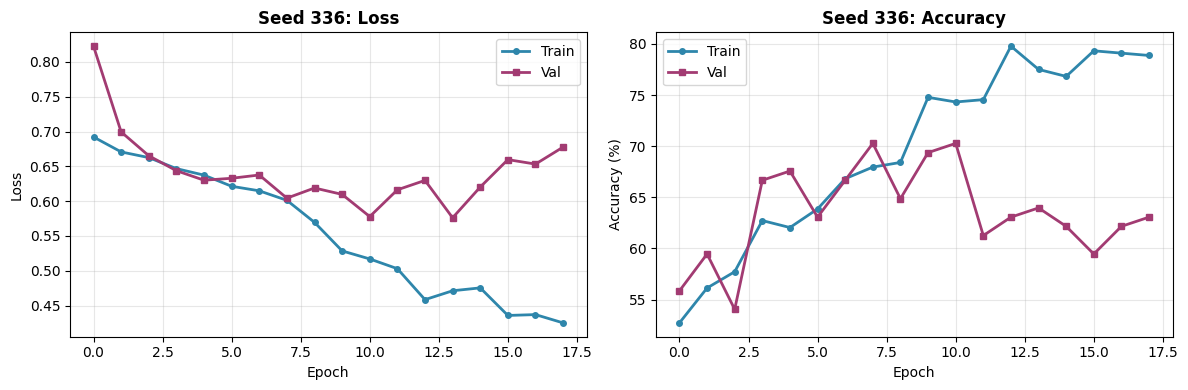

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

## Step 6: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.4f}")


Mean Validation Accuracy: 72.25% ± 1.17%
Mean Validation Loss: 0.5935 ± 0.0175
Mean Control Accuracy: 59.59% ± 8.34%
Mean Dementia Accuracy: 82.26% ± 5.47%
Mean F1 Score: 0.7677 ± 0.0110

Detailed Results:
Seed 21: Acc=72.97%, Loss=0.5926, Control Acc=63.27%, Dementia Acc=80.65%, F1=0.7692
Seed 42: Acc=72.07%, Loss=0.6065, Control Acc=63.27%, Dementia Acc=79.03%, F1=0.7597
Seed 84: Acc=72.97%, Loss=0.5637, Control Acc=69.39%, Dementia Acc=75.81%, F1=0.7581
Seed 168: Acc=72.97%, Loss=0.6004, Control Acc=53.06%, Dementia Acc=88.71%, F1=0.7857
Seed 336: Acc=70.27%, Loss=0.6043, Control Acc=48.98%, Dementia Acc=87.10%, F1=0.7660


## Step 7: Test Best Model on Multiple Datasets


In [15]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
else:
    best_idx = max_acc_indices[0]

# Get best model info
BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]
BEST_MODEL_PATH = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}" / "best.pth"

Multiple models with accuracy 72.97%, selecting one with lowest loss


In [16]:
# Load the best model
from model import AD_XLSR_Model
from test import test_on_dataset, test_on_dataset_with_val_csv

# Create model with XLSR configuration
test_model = AD_XLSR_Model()

# Load checkpoint (state_dict was saved directly)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
test_model.load_state_dict(checkpoint)
test_model = test_model.to(device)
test_model.eval()

# Define reference validation CSV for consistent testing across datasets
# Use Pitt-Best validation set as the reference for all three datasets
REFERENCE_VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-xlsr-val.csv"
print(f"Reference VAL_CSV: {REFERENCE_VAL_CSV}")

Reference VAL_CSV: /root/autodl-tmp/Few-Shot_is_all_you_need/ad_detection/data/processed/Pitt-origin-Resemble-xlsr-val.csv


In [17]:
with_val_csv_datasets = [
    ("Pitt", "data/raw/Pitt"),
    ("Pitt-Demucs", "data/denoised/Pitt-Demucs"),
    ("Pitt-Denoiser", "data/denoised/Pitt-Denoiser"),
    ("Pitt-FRCRN_SE", "data/denoised/Pitt-FRCRN_SE"),
    ("Pitt-MossFormer", "data/denoised/Pitt-MossFormer"),
    ("Pitt-Resemble", "data/denoised/Pitt-Resemble"),
]
all_test_results = {}
for name, audio_dir in with_val_csv_datasets:
    all_test_results[name] = test_on_dataset_with_val_csv(
        reference_val_csv=REFERENCE_VAL_CSV,
        dataset_name=name, model=test_model, device=device,
        ssl_model=ssl_model, raw_audio_dir=audio_dir)

test_datasets = [
    ("ADReSS", "data/raw/ADReSS"),
    ("Lu", "data/raw/Lu"),
    ("Lu-Demucs", "data/denoised/Lu-Demucs"),
    ("Lu-Denoiser", "data/denoised/Lu-Denoiser"),
    ("Lu-FRCRN_SE", "data/denoised/Lu-FRCRN_SE"),
    ("Lu-MossFormer", "data/denoised/Lu-MossFormer"),
    ("Lu-Resemble", "data/denoised/Lu-Resemble"),
]
for name, audio_dir in test_datasets:
    all_test_results[name] = test_on_dataset(
        dataset_name=name, model=test_model, device=device,
        ssl_model=ssl_model, raw_audio_dir=audio_dir)

# Print summary table
print("\n" + "="*80)
print("SUMMARY OF ALL TEST RESULTS")
print("="*80)
print(f"{'Dataset':<20} {'Accuracy':<12} {'F1 Score':<12} {'Control Acc':<12} {'Dementia Acc':<12}")
print("-"*80)

for dataset_name, results in all_test_results.items():
    print(f"{dataset_name:<20} {results['accuracy']*100:>10.2f}%  {results['f1']:>10.4f}  "
          f"{results['control_acc']*100:>10.2f}%  {results['dementia_acc']*100:>10.2f}%")

print("="*80)


Testing on Pitt Dataset (using reference VAL_CSV)

Reading reference VAL_CSV: /root/autodl-tmp/Few-Shot_is_all_you_need/ad_detection/data/processed/Pitt-origin-Resemble-xlsr-val.csv
Found 111 samples in reference VAL_CSV
Checking audio file existence in /root/autodl-tmp/Few-Shot_is_all_you_need/ad_detection/data/raw/Pitt...
Audio files found: 111/111

Creating target VAL_CSV: /root/autodl-tmp/Few-Shot_is_all_you_need/ad_detection/data/processed/Pitt-xlsr-val.csv
Target VAL_CSV created with 111 samples


=== Extracting XLSR features for Pitt Validation Set ===


Extracting Pitt Validation Set: 100%|██████████| 111/111 [00:00<00:00, 41516.65it/s]

Done: 0 extracted, 111 skipped, 0 errors (total 111)


Loading completed: 111 samples
Control: 49, Dementia: 62




Testing on Pitt: 100%|██████████| 4/4 [00:00<00:00, 13.21it/s]


...

Extracting Lu-Resemble Test Set: 100%|██████████| 74/74 [00:00<00:00, 35051.21it/s]

Done: 0 extracted, 74 skipped, 0 errors (total 74)


Loading completed: 74 samples
Control: 36, Dementia: 38




Testing on Lu-Resemble: 100%|██████████| 3/3 [00:00<00:00, 17.06it/s]

Overall Accuracy: 63.51%, F1 Score: 0.7158
Control Accuracy: 36.11%, Dementia Accuracy: 89.47%

SUMMARY OF ALL TEST RESULTS
Dataset              Accuracy     F1 Score     Control Acc  Dementia Acc
--------------------------------------------------------------------------------
Pitt                      56.76%      0.6418       40.82%       69.35%
Pitt-Demucs               55.86%      0.6202       44.90%       64.52%
Pitt-Denoiser             61.26%      0.7226       24.49%       90.32%
Pitt-FRCRN_SE             63.96%      0.7183       40.82%       82.26%
Pitt-MossFormer           63.96%      0.7143       42.86%       80.65%
Pitt-Resemble             58.56%      0.6618       40.82%       72.58%
ADReSS                    69.87%      0.7345       56.41%       83.33%
Lu                        37.84%      0.2812       52.78%       23.68%
Lu-Demucs                 40.54%      0.4054       41.67%       39.47%
Lu-Denoiser               56.76%      0.7037       11.11%      100.00%
Lu-FRCRN_SE 

In [18]:
torch.cuda.empty_cache()